# 26. To build an autoencoder for image denoising using MNIST dataset.

## Aim

To build an autoencoder for image denoising using the MNIST dataset.

## Theory

An autoencoder is a neural network that learns to reconstruct input images.

In this practical, noise is added to MNIST images. The autoencoder learns to remove the noise and reconstruct clean images.

In [1]:
#Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.17.0


In [2]:
#Load MNIST Dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training Data:", x_train.shape)
print("Testing Data:", x_test.shape)

Training Data: (60000, 28, 28)
Testing Data: (10000, 28, 28)


In [4]:
#Add Noise
noise_factor = 0.3

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print("Noise added successfully.")

Noise added successfully.


In [5]:
#Build Autoencoder
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(28 * 28, activation="sigmoid"),
    layers.Reshape((28, 28))
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

model.summary()

C:\Users\Smit\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 784)                 │         101,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 28, 28)              │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 218,192 (852.31 KB)

 Trainable params: 218,192 (852.31 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
#Train Autoencoder
history = model.fit(
    x_train_noisy,
    x_train,
    epochs=5,
    batch_size=128,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.2751 - val_loss: 0.1384
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.1340 - val_loss: 0.1197
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.1187 - val_loss: 0.1121
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.1118 - val_loss: 0.1070
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.1075 - val_loss: 0.1042


In [7]:
#Denoise Images
denoised_images = model.predict(x_test_noisy[:5])

print("Denoising completed.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
Denoising completed.


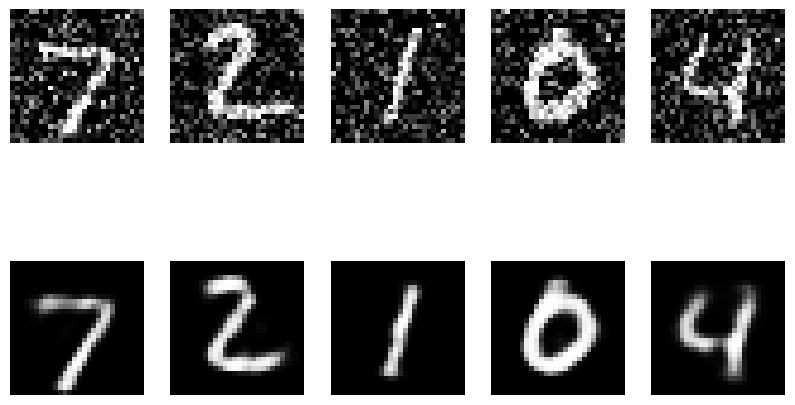

In [8]:
#Display Results
plt.figure(figsize=(10, 6))

for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_noisy[i], cmap="gray")
    plt.axis("off")

    plt.subplot(2, 5, i + 6)
    plt.imshow(denoised_images[i], cmap="gray")
    plt.axis("off")

plt.show()

## Result

An autoencoder was successfully built and trained to remove noise from MNIST images and reconstruct clean images.